In [177]:
import torch
from torch.distributed.algorithms.ddp_comm_hooks.powerSGD_hook import batched_powerSGD_hook
from torch.distributions import Dirichlet, Categorical, Normal
import matplotlib.pyplot as plt
import matplotlib as mpl
import mpltern
import numpy as np
import pandas as pd

# Create synthetic classification dataset

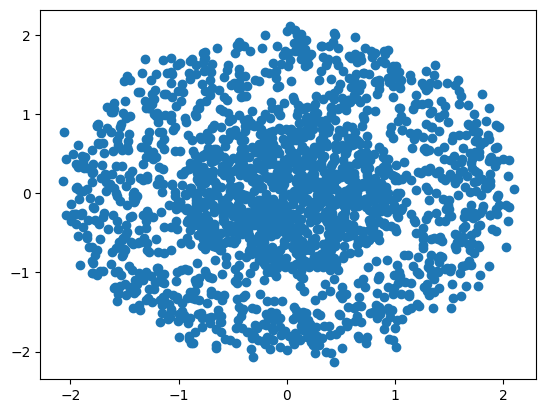

In [178]:
def generate_ring_dataset(n_samples=1000, inner_radius=1.0, outer_radius=2.0, noise=0.1, plot=False):
    """
    Generate a synthetic dataset with class 0 in the center and class 1 in a surrounding ring.

    Parameters:
        n_samples (int): Total number of samples.
        inner_radius (float): Radius threshold for class 0.
        outer_radius (float): Outer boundary of the data.
        noise (float): Standard deviation of Gaussian noise added to points.
        plot (bool): Whether to plot the generated dataset.

    Returns:
        X (ndarray): Feature matrix of shape (n_samples, 2).
        y (ndarray): Labels of shape (n_samples,).
    """
    n0 = n_samples // 2  # Class 0
    n1 = n_samples - n0  # Class 1

    # Class 0: Points within the inner radius
    r0 = inner_radius * np.sqrt(np.random.rand(n0))
    theta0 = 2 * np.pi * np.random.rand(n0)
    x0 = np.stack([r0 * np.cos(theta0), r0 * np.sin(theta0)], axis=1)
    x0 += noise * np.random.randn(n0, 2)

    # Class 1: Points in the ring between inner_radius and outer_radius
    r1 = inner_radius + (outer_radius - inner_radius) * np.sqrt(np.random.rand(n1))
    theta1 = 2 * np.pi * np.random.rand(n1)
    x1 = np.stack([r1 * np.cos(theta1), r1 * np.sin(theta1)], axis=1)
    x1 += noise * np.random.randn(n1, 2)

    # Combine
    X = np.vstack([x0, x1])

    return X.astype(np.float32)

INNER_RADIUS = 1
OUTER_RADIUS = 2
data = generate_ring_dataset(n_samples=2000,inner_radius=INNER_RADIUS, outer_radius=OUTER_RADIUS,noise=0.1, plot=True)
plt.scatter(data[:, 0], data[:, 1])

# Define True Target Probability Distribution

In [179]:
# define 1st order probability distribution

def generate_y_probs(points):
    center = np.array([0.0, 0.0])

    # Compute Euclidean distance from center
    distances = np.linalg.norm(points - center, axis=1, ord=2)

    # Normalize distance to [0, 1] within the transition region
    normalized_r = (distances - INNER_RADIUS) / (OUTER_RADIUS - INNER_RADIUS)

    # Sigmoid-based transition
    p1 = 1 / (1 + np.exp(- (normalized_r - 0.5)))
    p0 = 1 - p1

    return torch.from_numpy(np.stack([p0, p1], axis=-1))

def generate_target_and_probs(points):
    y_probs = generate_y_probs(points)
    y_labels = torch.argmax(y_probs, dim=1)
    return y_labels, y_probs

y_labels, y_probs = generate_target_and_probs(torch.tensor(data))
y_probs

/var/folders/r0/h4rkplrj2qldt4_b_tdjz3cc0000gn/T/ipykernel_21325/3526802814.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  distances = np.linalg.norm(points - center, axis=1, ord=2)


tensor([[0.6473, 0.3527],
        [0.7712, 0.2288],
        [0.6966, 0.3034],
        ...,
        [0.5101, 0.4899],
        [0.3792, 0.6208],
        [0.4984, 0.5016]], dtype=torch.float64)

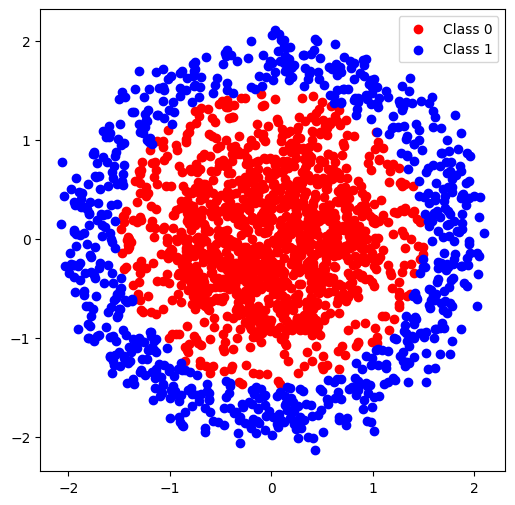

In [180]:
fig ,ax = plt.subplots(figsize=(6,6))
ax.scatter(data[y_labels == 0, 0], data[y_labels == 0, 1],c="red", label="Class 0")
ax.scatter(data[y_labels == 1, 0], data[y_labels == 1, 1],c="blue", label="Class 1")
plt.legend()
plt.show()

# Define Ensemble

In [181]:
from epiuc.uncertainty.classification import MLP_Classifier
from epiuc.uncertainty.wrapper import Ensemble_Classifier, MC_Classifier
ENSEMBLE_MEMBER_COUNT = 10
base_ensemble = [MLP_Classifier(input_shape=2,n_classes=2,n_layers=2,num_neurons=10,dropout_prob=0,batch_norm=False,) for  _ in range(ENSEMBLE_MEMBER_COUNT)]
ensemble_model = Ensemble_Classifier(base_ensemble,n_models=10)
#ensemble_model.fit(data,y_labels)
#ensemble_model.save("models/Ensemble_Ball/")
ensemble_model.load("models/Ensemble_Ball/")

In [182]:
def ensemble_probs(points):
    probs,_ = ensemble_model.predict(points,raw_output=True)
    return probs
y_probs_ensemble_points = ensemble_probs(data)
y_pred_ensemble_points = y_probs_ensemble_points.mean(dim=1).argmax(dim=1)

In [183]:
def total_uncertainty_ensemble(y_probs_ensemble):
    y_probs_mean = y_probs_ensemble.mean(dim=1)
    return y_probs_mean.mul(y_probs_mean.log2()).sum(dim=-1).mul(-1)

def aleatoric_uncertainty_ensemble(y_probs_ensemble):
    return y_probs_ensemble.mul(y_probs_ensemble.log2()).sum(dim=-1).mul(-1).mean(dim=1)

def epistemic_uncertainty_ensemble(y_probs_ensemble):
    return (total_uncertainty_ensemble(y_probs_ensemble) - aleatoric_uncertainty_ensemble(y_probs_ensemble)).clip(0,1)

# Visualize Data

/var/folders/r0/h4rkplrj2qldt4_b_tdjz3cc0000gn/T/ipykernel_21325/3526802814.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  distances = np.linalg.norm(points - center, axis=1, ord=2)


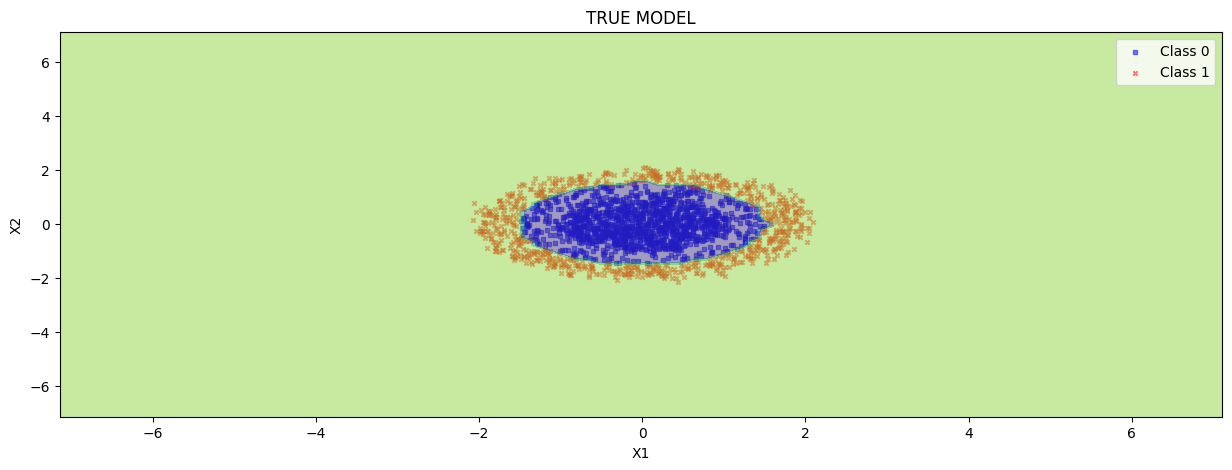

In [184]:
# visualize the labels distribution for the points
def visualize_labels_distribution(points,y_labels):
     # Create gird of points
    grid_points = np.linspace(points.min()-5, points.max()+5, 100)
    xx,yy = np.meshgrid(grid_points, grid_points)
    grid_points = np.array([xx.flatten(), yy.flatten()]).T
    # Get the labels of the grid_points
    grid_y_labels,_ = generate_target_and_probs(torch.tensor(grid_points))
    gird_y_labels = grid_y_labels.numpy()

    # Plot the points
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))

    # Plot TU
    # Plot class 0
    ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
    # Plot class 1
    ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')
    ax.contourf(xx, yy, grid_y_labels.reshape(xx.shape),levels=2, alpha=0.5)
    ax.set_title("TRUE MODEL")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")

    plt.legend()
    plt.show()

visualize_labels_distribution(data,y_labels)

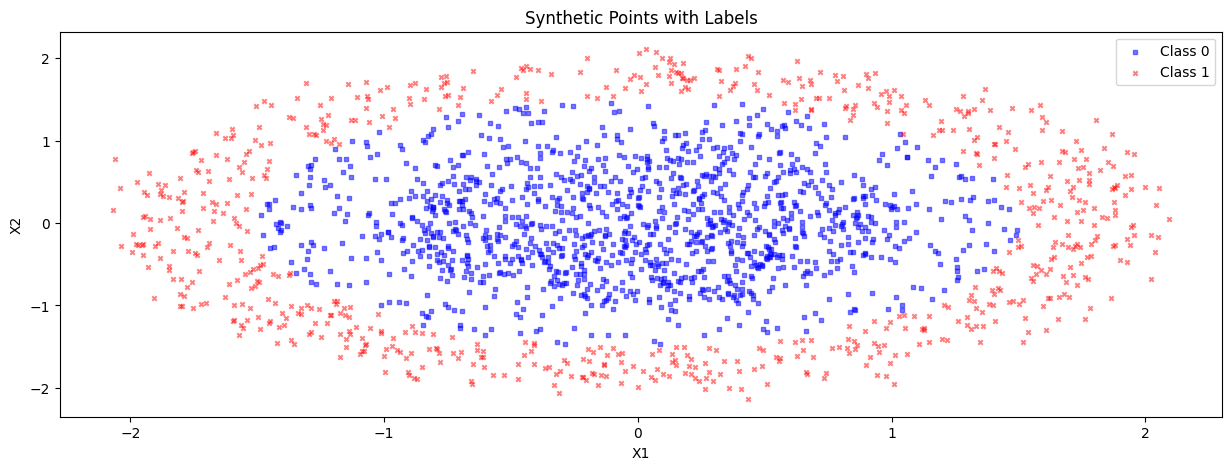

In [185]:
# Visualize the points and the labels
def visualize_points_and_labels(points, y_labels):
    """
    Visualize the points and the labels.
    """
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))
    # Plot class 0
    ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
    # Plot class 1
    ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')
    ax.set_title("Synthetic Points with Labels")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    plt.legend()
    plt.show()

# Visualize points and labels
visualize_points_and_labels(data, y_labels)

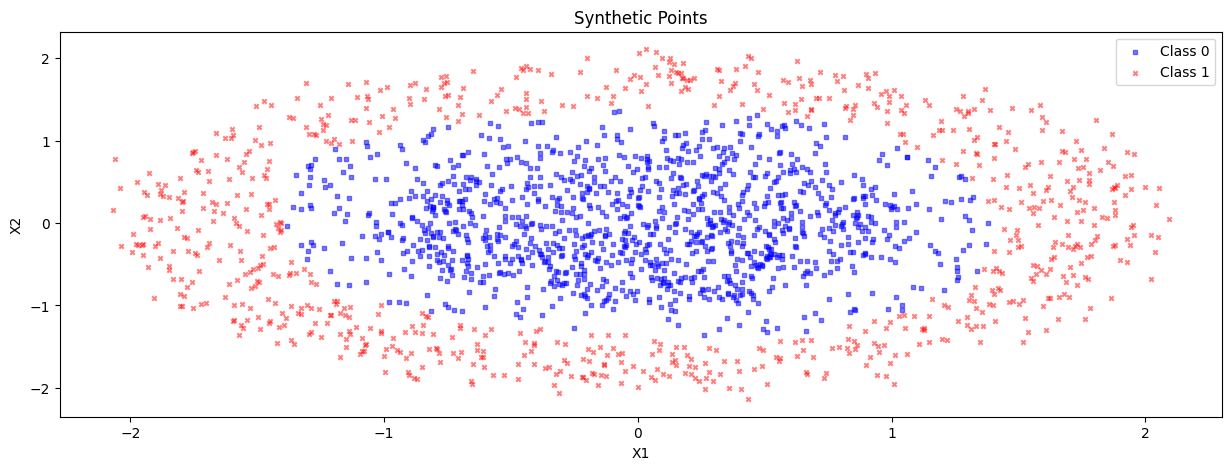

In [186]:
# visualize predictions of the ensemble
# Visualize the points and the labels
def visualize_points_and_labels(points, y_labels):
    """
    Visualize the points and the labels.
    """
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))
    # Plot class 0
    ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
    # Plot class 1
    ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')
    ax.set_title("Synthetic Points")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    plt.legend()
    plt.show()


# Visualize points and labels
visualize_points_and_labels(data, y_pred_ensemble_points)


# Visualize AU/EU/TU

torch.Size([10000, 10, 2])
tensor(0.0042, grad_fn=<MinBackward1>) tensor(1.0000, grad_fn=<MaxBackward1>)


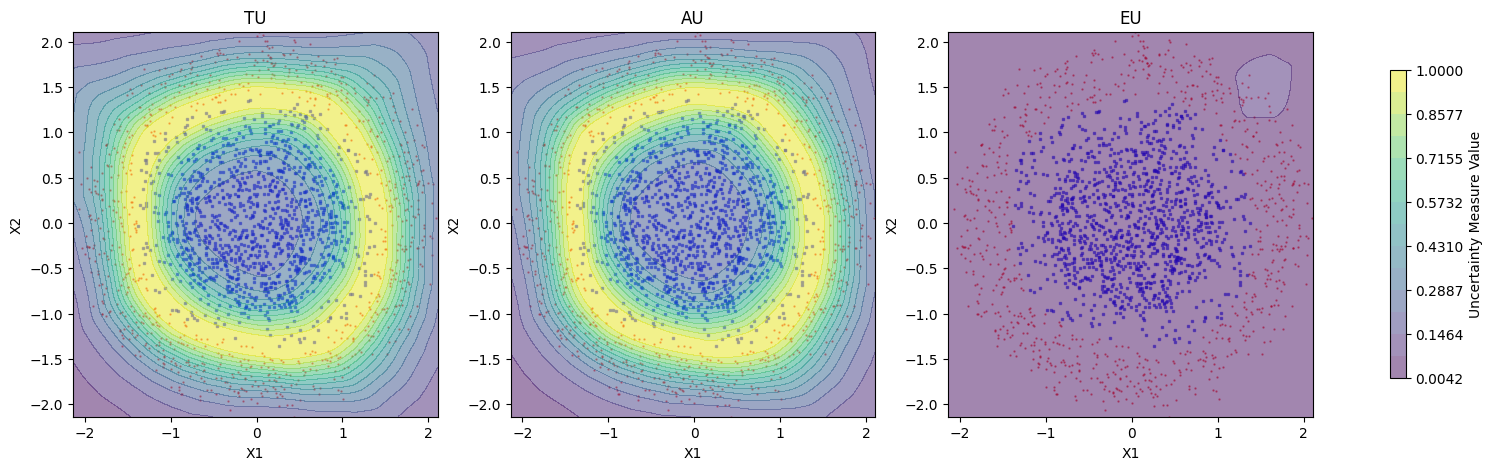

In [187]:
# Look at a given point and AU,EU,TU
def visualize_au_eu_tu_points(points,y_labels):
    """
    Visualize a given point and its AU, EU, and TU.
    """
    # Create gird of points
    grid_points = np.linspace(points.min(), points.max(), 100)
    xx,yy = np.meshgrid(grid_points, grid_points)
    grid_points = np.array([xx.flatten(), yy.flatten()]).T
    # Get the labels of the grid_points
    y_probs_ensemble = ensemble_probs(torch.tensor(grid_points))
    print(y_probs_ensemble.shape)
    total_uncertainty = total_uncertainty_ensemble(y_probs_ensemble)
    aleatoric_uncertainty = aleatoric_uncertainty_ensemble(y_probs_ensemble)
    epistemic_uncertainty = epistemic_uncertainty_ensemble(y_probs_ensemble)

    # Shared value range
    all_vals = torch.concatenate([total_uncertainty, aleatoric_uncertainty, epistemic_uncertainty], dim=0)
    vmin = all_vals.min()
    vmax = all_vals.max()
    print(vmin, vmax)

    # Define shared levels and normalization
    levels = torch.linspace(vmin, vmax, 15)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = mpl.cm.viridis

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 5))

    plots = []
    for ax, values, title in zip(axes, [total_uncertainty, aleatoric_uncertainty, epistemic_uncertainty], ["TU", "AU", "EU"]):
        # Scatter data
        ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=2, alpha=0.5, color='blue', label='Class 0')
        ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='.', s=2, alpha=0.5, color='red', label='Class 1')

        # Unified contourf
        contour = ax.contourf(xx, yy, values.detach().numpy().reshape(xx.shape), levels=levels, cmap=cmap, norm=norm, alpha=0.5)
        plots.append(contour)

        ax.set_title(title)
        ax.set_xlabel("X1")
        ax.set_ylabel("X2")

    # Single shared colorbar using one of the contour handles
    fig.colorbar(plots[0], ax=axes.ravel().tolist(), shrink=0.8, label="Uncertainty Measure Value")

    plt.show()
visualize_au_eu_tu_points(data,y_pred_ensemble_points)

# Visualize EU STD

In [188]:
def sample_delta_ball(reference_point, delta, n_points):
    """
    :param point:
    :param delta:
    :param norm:
    :return:
    """
    delta_samples = []
    for _ in range(n_points):
        sample = np.random.randn(*reference_point.shape)
        sample /= np.linalg.norm(sample,ord=2,axis=-1, keepdims=True)
        delta_sample = sample  * delta
        delta_samples.append([delta_sample])
    samples = np.concatenate(delta_samples,axis=0)
    delta_samples = (reference_point + samples).astype(np.float32)
    return torch.tensor(delta_samples.reshape(-1,2)).requires_grad_(True)

tensor(0.0018, grad_fn=<MinBackward1>) tensor(0.0960, grad_fn=<MaxBackward1>)


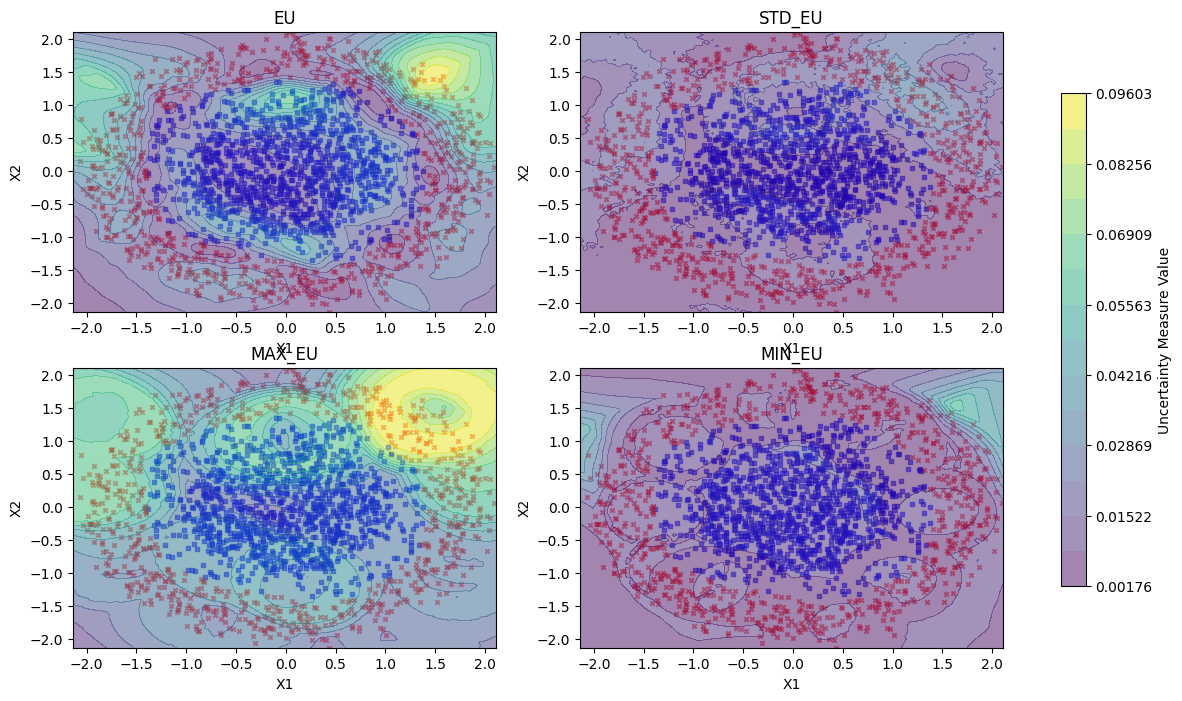

In [189]:
# visualize how std of eu looks like aroung the points
def visualize_eu_std_points(points,y_labels, delta=1, n_points=10):
    """
    Visualize a given point and its AU, EU, and TU.
    """
    # Create gird of points
    grid_points = np.linspace(points.min(), points.max(), 100)
    xx,yy = np.meshgrid(grid_points, grid_points)
    grid_points = np.array([xx.flatten(), yy.flatten()]).T

    # Extract loss value
    tensor_points = torch.tensor(grid_points)
    probs_ensemble  = ensemble_probs(tensor_points)
    probs = probs_ensemble.mean(dim=0)
    epistemic_uncertainty = epistemic_uncertainty_ensemble(probs_ensemble)


    # sample_ball
    delta_ball = sample_delta_ball(tensor_points.detach().numpy(),delta,n_points)
    probs_ensemble_delta_ball = ensemble_probs(delta_ball.view(-1,2))
    probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
    eu_delta_ball = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball).view(n_points,-1)


    std_eu_ball = torch.std(eu_delta_ball,dim=0)
    max_eu_ball = torch.max(eu_delta_ball,dim=0)[0]
    min_eu_ball = torch.min(eu_delta_ball,dim=0)[0]
    mean_eu_ball = torch.mean(eu_delta_ball,dim=0)


    # Shared value range
    all_vals = torch.concatenate([std_eu_ball, epistemic_uncertainty, max_eu_ball, min_eu_ball], dim=0)
    vmin = all_vals.min()
    vmax = all_vals.max()
    print(vmin, vmax)

    # Define shared levels and normalization
    levels = torch.linspace(vmin, vmax, 15)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = mpl.cm.viridis

    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 8))

    plots = []
    for ax, data, title in zip(axes.flatten(), [epistemic_uncertainty, std_eu_ball, max_eu_ball, min_eu_ball], ["EU","STD_EU", "MAX_EU", "MIN_EU"]):
        # Scatter data
        ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
        ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')

        # Unified contourf
        contour = ax.contourf(xx, yy, data.detach().numpy().reshape(xx.shape), levels=levels, cmap=cmap, norm=norm, alpha=0.5)
        plots.append(contour)

        ax.set_title(title)
        ax.set_xlabel("X1")
        ax.set_ylabel("X2")

    # Single shared colorbar using one of the contour handles
    fig.colorbar(plots[0], ax=axes.ravel().tolist(), shrink=0.8, label="Uncertainty Measure Value")

    plt.show()
visualize_eu_std_points(data,y_pred_ensemble_points,delta=0.5,n_points=100)

tensor(0.0060, grad_fn=<MinBackward1>) tensor(0.9945, grad_fn=<MaxBackward1>)


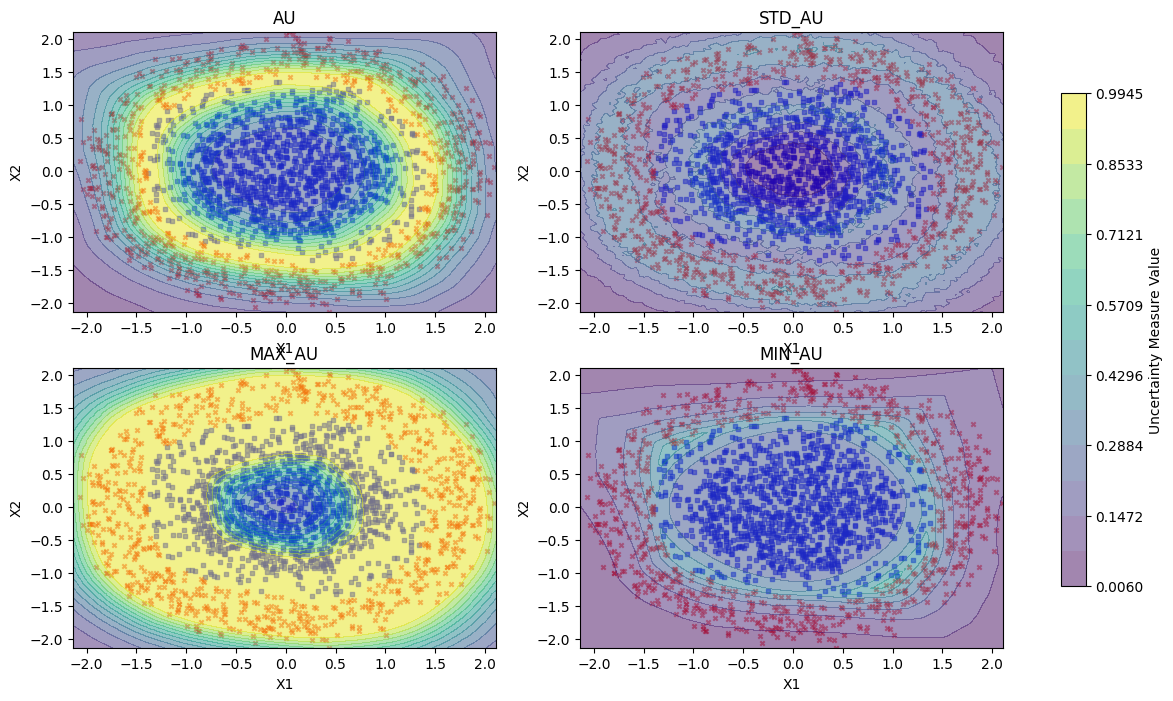

In [190]:
# visualize how std of eu looks like aroung the points
def visualize_eu_std_points(points,y_labels, delta=1, n_points=10):
    """
    Visualize a given point and its AU, EU, and TU.
    """
    # Create gird of points
    grid_points = np.linspace(points.min(), points.max(), 100)
    xx,yy = np.meshgrid(grid_points, grid_points)
    grid_points = np.array([xx.flatten(), yy.flatten()]).T

    # Extract loss value
    tensor_points = torch.tensor(grid_points)
    probs_ensemble  = ensemble_probs(tensor_points)
    probs = probs_ensemble.mean(dim=0)
    aleatoric_uncertainty = aleatoric_uncertainty_ensemble(probs_ensemble)


    # sample_ball
    delta_ball = sample_delta_ball(tensor_points.detach().numpy(),delta,n_points)
    probs_ensemble_delta_ball = ensemble_probs(delta_ball.view(-1,2))
    probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
    au_delta_ball = aleatoric_uncertainty_ensemble(probs_ensemble_delta_ball).view(n_points,-1)



    std_au_ball = torch.std(au_delta_ball,dim=0)
    max_au_ball = torch.max(au_delta_ball,dim=0)[0]
    min_au_ball = torch.min(au_delta_ball,dim=0)[0]


    # Shared value range
    all_vals = torch.concatenate([std_au_ball, aleatoric_uncertainty, max_au_ball, min_au_ball], dim=0)
    vmin = all_vals.min()
    vmax = all_vals.max()
    print(vmin, vmax)

    # Define shared levels and normalization
    levels = torch.linspace(vmin, vmax, 15)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = mpl.cm.viridis

    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 8))

    plots = []
    for ax, data, title in zip(axes.flatten(), [aleatoric_uncertainty, std_au_ball, max_au_ball, min_au_ball], ["AU","STD_AU", "MAX_AU", "MIN_AU"]):
        # Scatter data
        ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
        ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')

        # Unified contourf
        contour = ax.contourf(xx, yy, data.detach().numpy().reshape(xx.shape), levels=levels, cmap=cmap, norm=norm, alpha=0.5)
        plots.append(contour)

        ax.set_title(title)
        ax.set_xlabel("X1")
        ax.set_ylabel("X2")

    # Single shared colorbar using one of the contour handles
    fig.colorbar(plots[0], ax=axes.ravel().tolist(), shrink=0.8, label="Uncertainty Measure Value")

    plt.show()
visualize_eu_std_points(data,y_pred_ensemble_points,delta=0.5,n_points=100)

# CF construction

In [191]:
MAX_STEPS = 1000
UNCERTAINTY_STEP_INCREASE = 1e-2
DESIRED_VALIDITY = 0.9
#point_of_interest = torch.tensor(np.array([-1,0]).reshape(-1,2), dtype=torch.float,requires_grad=True)
point_of_interest = torch.tensor(np.array([0, -2]).reshape(-1,2), dtype=torch.float,requires_grad=True)
point_of_interest_label = torch.tensor(np.array([1]))
desired_class = 0

## Validity
We now work in the scenario of creating a valid counter factual for our point x

In [192]:
from property_procedures.valid import validity_procedure

cf_valid, cf_steps_valid = validity_procedure(point_of_interest,probability_function=ensemble_probs,desired_class=desired_class,MAX_STEPS=MAX_STEPS)

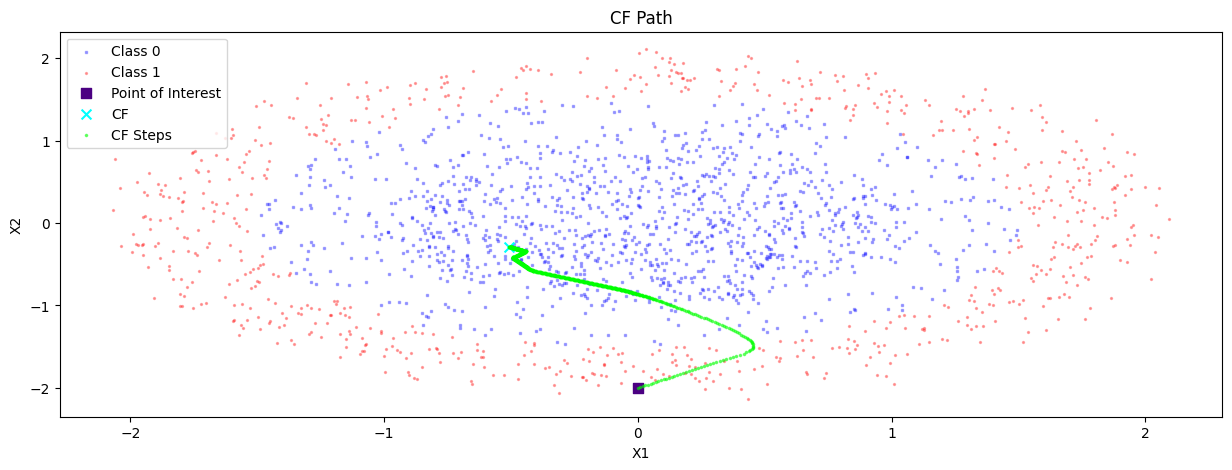

In [193]:
def visualize_cf_and_steps(cf,cf_steps, points, y_labels):
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))

    # visualize the data itself
    ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=2, alpha=0.3, color='blue', label='Class 0')
    ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='o', s=2, alpha=0.3, color='red', label='Class 1')

    ax.scatter(point_of_interest[:,0].detach(), point_of_interest[:,1].detach(), marker='s', s=50, alpha=1, color='indigo', label="Point of Interest")

    ax.scatter(cf[:,0], cf[:,1], marker='x', s=50, color='aqua', label="CF")

    ax.scatter(cf_steps[:,0], cf_steps[:,1], marker='.', s=10, alpha=0.5, color='lime', label="CF Steps")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_title("CF Path")

    plt.legend()
visualize_cf_and_steps(cf_valid, cf_steps_valid, data, y_labels)

## Plausability

In [194]:
from property_procedures.plausable import plausability_procedure

cf_plausable, cf_steps_plausable = plausability_procedure(point_of_interest,probability_function=ensemble_probs,epistemic_uncertainty_function=epistemic_uncertainty_ensemble, desired_class=desired_class,MAX_STEPS=MAX_STEPS)

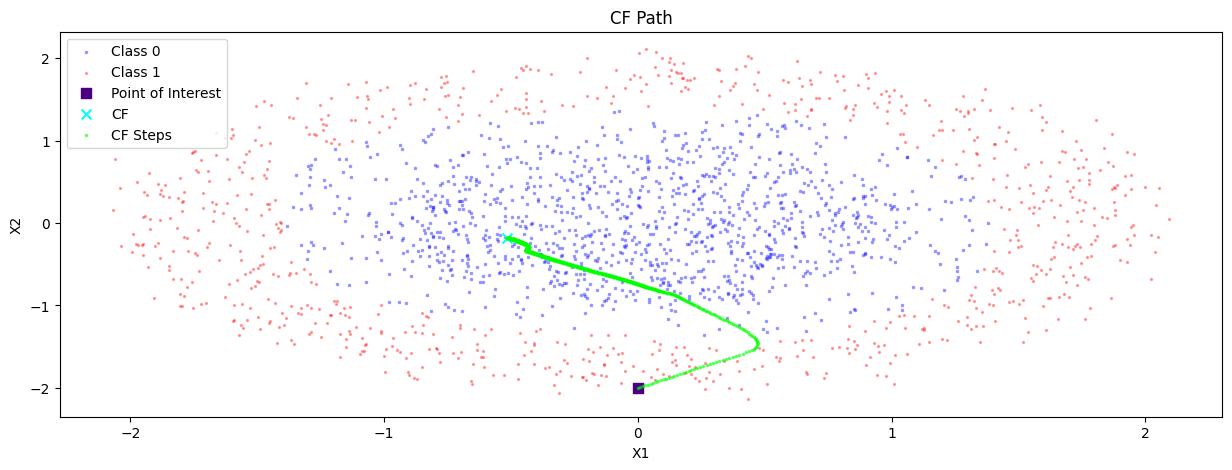

In [195]:
visualize_cf_and_steps(cf_plausable, cf_steps_plausable, data, y_pred_ensemble_points)

In [196]:
cf_plausable, cf_valid

(tensor([[-0.5154, -0.1775]]), tensor([[-0.5074, -0.2870]]))

In [197]:
epistemic_uncertainty_ensemble(ensemble_probs(cf_plausable)), epistemic_uncertainty_ensemble(ensemble_probs(cf_valid))

(tensor([0.0105], grad_fn=<ClampBackward1>),
 tensor([0.0119], grad_fn=<ClampBackward1>))

## Discrimitiveness

In [198]:
from property_procedures.discriminative import discriminiative_procedure
cf_discriminiative, cf_steps_discriminiative = discriminiative_procedure(point_of_interest,probability_function=ensemble_probs,aleatoric_uncertainty_function=aleatoric_uncertainty_ensemble, desired_class=desired_class,MAX_STEPS=MAX_STEPS)

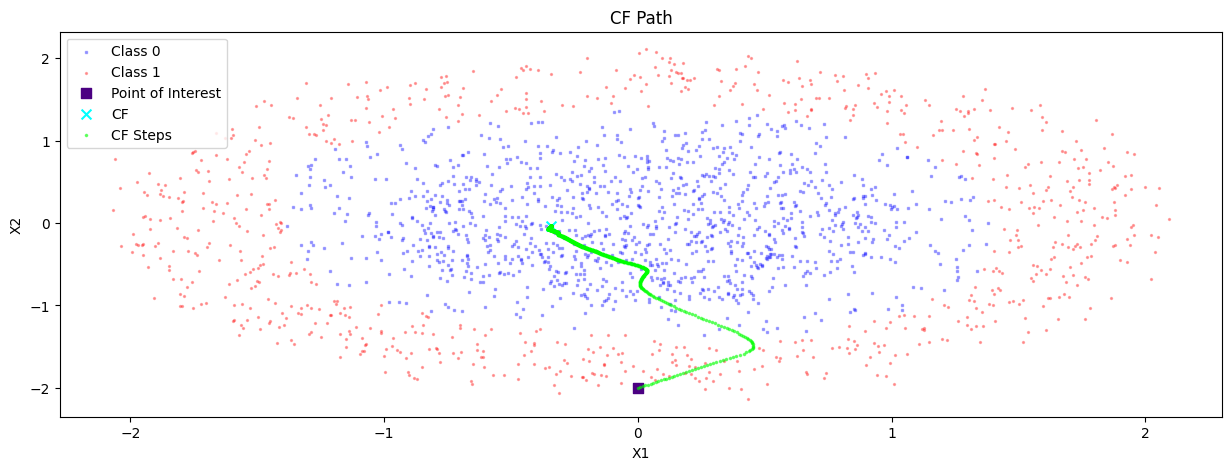

In [199]:
visualize_cf_and_steps(cf_discriminiative, cf_steps_discriminiative, data, y_pred_ensemble_points)


In [200]:
cf_discriminiative, cf_plausable, cf_valid

(tensor([[-0.3417, -0.0338]]),
 tensor([[-0.5154, -0.1775]]),
 tensor([[-0.5074, -0.2870]]))

In [201]:
aleatoric_uncertainty_ensemble(ensemble_probs(cf_plausable)), aleatoric_uncertainty_ensemble(ensemble_probs(cf_valid)), aleatoric_uncertainty_ensemble(ensemble_probs(cf_discriminiative))


(tensor([0.2503], grad_fn=<MeanBackward1>),
 tensor([0.2666], grad_fn=<MeanBackward1>),
 tensor([0.2311], grad_fn=<MeanBackward1>))

## Stability

In [202]:
from property_procedures.stability import stable_procedure_baseline

cf_stable_baseline, cf_steps_stable_baseline = stable_procedure_baseline(point_of_interest,probability_function=ensemble_probs,desired_class=desired_class,MAX_STEPS=MAX_STEPS)


In [203]:
from property_procedures.stability import stable_procedure_tu_start_ball

cf_stable_start_ball, cf_steps_stable_start_ball = stable_procedure_tu_start_ball(point_of_interest,probability_function=ensemble_probs,aleatoric_uncertainty_function=aleatoric_uncertainty_ensemble,epistemic_uncertainty_function=epistemic_uncertainty_ensemble,total_uncertainty_function=total_uncertainty_ensemble,desired_class=desired_class, delta=0.2, n_points=10)

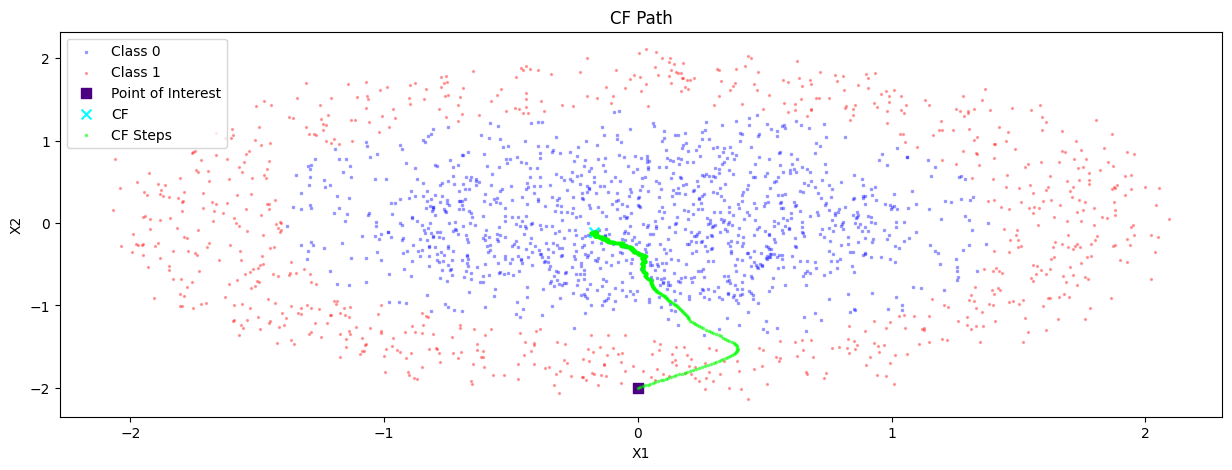

In [204]:
visualize_cf_and_steps(cf_stable_start_ball,cf_steps_stable_start_ball, data, y_pred_ensemble_points)

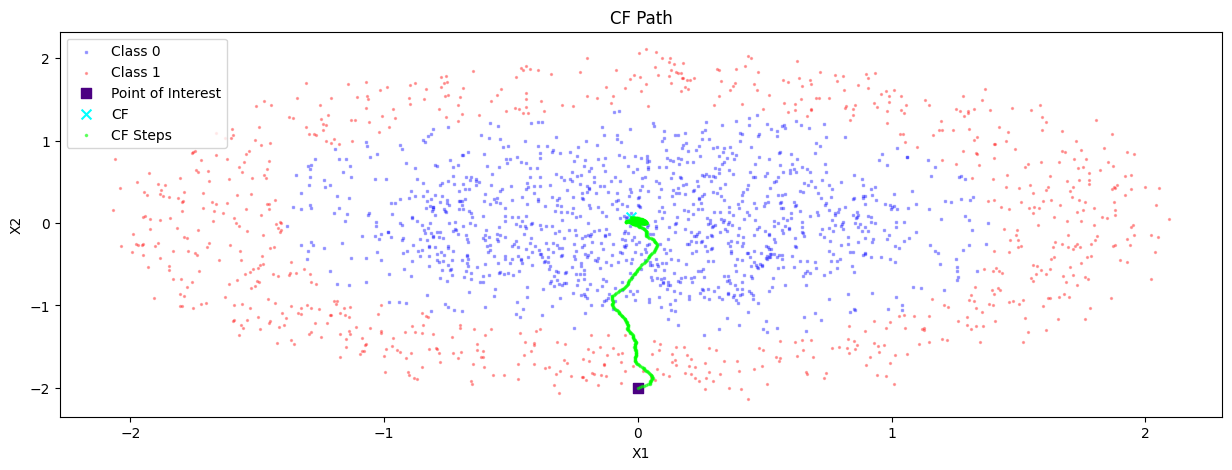

In [205]:
visualize_cf_and_steps(cf_stable_baseline,cf_steps_stable_baseline, data, y_pred_ensemble_points)


In [206]:
delta_point_of_interest = sample_delta_ball(point_of_interest.detach().numpy(), delta=0.1, n_points=10)
cf_points_baseline = []
cf_points_start_ball = []
for point in delta_point_of_interest:
    cf_baseline, _ = stable_procedure_baseline(point.view(-1, 2), probability_function=ensemble_probs, desired_class=desired_class, MAX_STEPS=MAX_STEPS)
    cf_start_ball,_ = stable_procedure_tu_start_ball(point.view(-1, 2), probability_function=ensemble_probs, aleatoric_uncertainty_function=aleatoric_uncertainty_ensemble, epistemic_uncertainty_function=epistemic_uncertainty_ensemble, total_uncertainty_function=total_uncertainty_ensemble, desired_class=desired_class, delta=0.2, n_points=10)

    #visualize_cf_and_steps(cf_point, cf_steps_point, points, y_pred_ensemble_points)
    cf_points_baseline.append(cf_baseline)
    cf_points_start_ball.append(cf_start_ball)

# compare with validitiy procedure
cf_points_not_stable =[]
for point in delta_point_of_interest:
    cf_point, cf_steps_point = validity_procedure(point.view(-1,2), probability_function=ensemble_probs, desired_class=desired_class, MAX_STEPS=MAX_STEPS)
    #visualize_cf_and_steps(cf_point, cf_steps_point, points, y_pred_ensemble_points)
    cf_points_not_stable.append(cf_point)


# compute the mean l2 distance for stable and not stable
l2_distances_baseline = [
    torch.norm(p1 - p2, p=2).item()
    for p1 in cf_points_baseline
    for p2 in cf_points_baseline
    if (p1 != p2).all()
]
l2_distances_start_ball = [
    torch.norm(p1 - p2, p=2).item()
    for p1 in cf_points_start_ball
    for p2 in cf_points_start_ball
    if (p1 != p2).all()
]
l2_distances_unstable = [
    torch.norm(p1 - p2, p=2).item()
    for p1 in cf_points_not_stable
    for p2 in cf_points_not_stable
    if (p1 != p2).all()
]

print("Mean L2-Distance of Stable Procedure BASELINE: ", np.mean(l2_distances_baseline), " +/- ", np.std(l2_distances_baseline))
print("Mean L2-Distance of Stable Procedure START BALL: ", np.mean(l2_distances_start_ball), " +/- ", np.std(l2_distances_start_ball))
print("Mean L2-Distance of Unstable Procedure: ", np.mean(l2_distances_unstable), " +/- ",  np.std(l2_distances_unstable))

Mean L2-Distance of Stable Procedure BASELINE:  0.026282337695981064  +/-  0.014704352759966743
Mean L2-Distance of Stable Procedure START BALL:  0.018780411968732046  +/-  0.010392305552802858
Mean L2-Distance of Unstable Procedure:  0.010337902384344488  +/-  0.006542143697814446


## Robustness

In [207]:
from property_procedures.robust import robust_procedure

cf_robust, cf_steps_robust = robust_procedure(point_of_interest,probability_function=ensemble_probs,epistemic_uncertainty_function=epistemic_uncertainty_ensemble,aleatoric_uncertainty_function=aleatoric_uncertainty_ensemble,desired_class=desired_class,MAX_STEPS=MAX_STEPS)

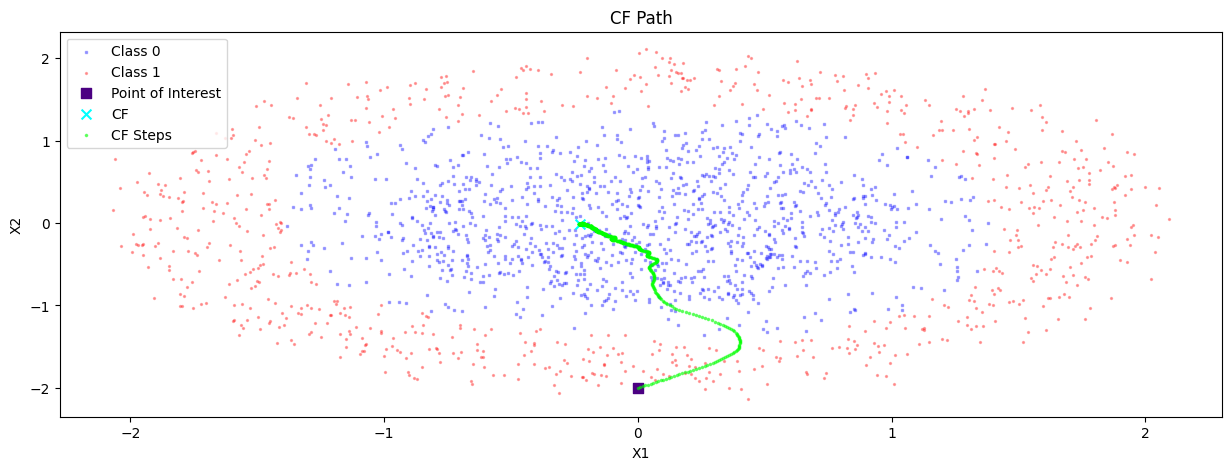

In [208]:
visualize_cf_and_steps(cf_robust,cf_steps_robust, data, y_pred_ensemble_points)

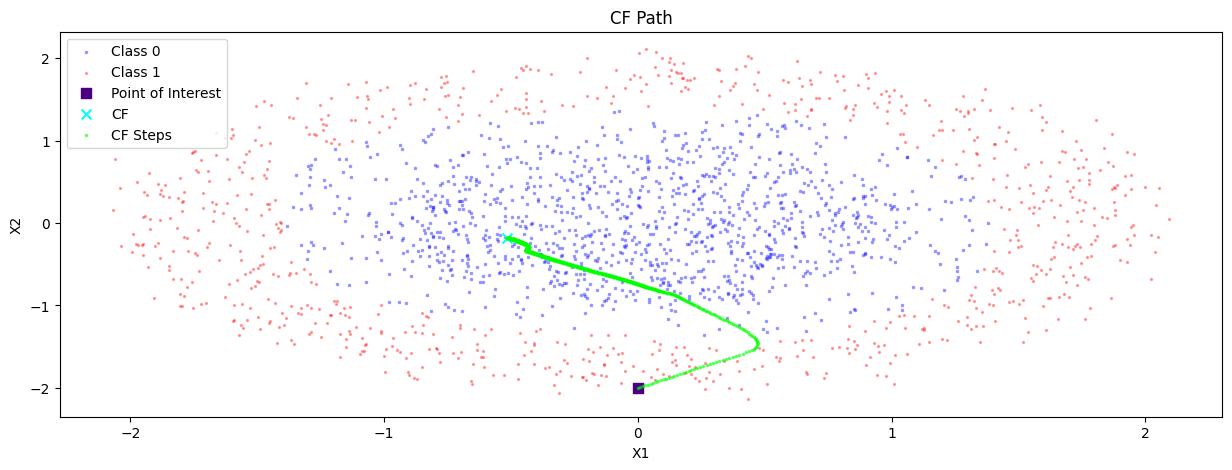

In [209]:
visualize_cf_and_steps(cf_plausable, cf_steps_plausable, data, y_pred_ensemble_points)

In [210]:
epistemic_uncertainty_ensemble(ensemble_probs(cf_robust)), epistemic_uncertainty_ensemble(ensemble_probs(cf_plausable))

(tensor([0.0114], grad_fn=<ClampBackward1>),
 tensor([0.0105], grad_fn=<ClampBackward1>))

In [211]:

res_mean = []
res_std = []
for _ in range(10):
    delta_cf_robust = sample_delta_ball(cf_robust.detach().numpy(), delta=0.2, n_points=100)
    epistemic_cf_robust = []
    for point in delta_cf_robust:
        #visualize_cf_and_steps(cf_point, cf_steps_point, points, y_pred_ensemble_points)
        epistemic_cf_robust.append(
            epistemic_uncertainty_ensemble(ensemble_probs(point.view(-1,2))).detach().numpy()
        )

    delta_cf_plausable = sample_delta_ball(cf_plausable.detach().numpy(), delta=0.2, n_points=100)
    epistemic_cf_plausable = []
    for point in delta_cf_plausable:
        #visualize_cf_and_steps(cf_point, cf_steps_point, points, y_pred_ensemble_points)
        epistemic_cf_plausable.append(
            epistemic_uncertainty_ensemble(ensemble_probs(point.view(-1,2))).detach().numpy()
        )

    print("Std Epistemic Uncertainty of Robust Procedure: ",np.mean(epistemic_cf_robust) , " +/- " ,  np.std(epistemic_cf_robust))
    print("Std Epistemic Uncertainty of Plausable Procedure: ", np.mean(epistemic_cf_plausable) , " +/- " , np.std(epistemic_cf_plausable))

    res_mean.append([np.mean(epistemic_cf_robust), np.mean(epistemic_cf_plausable)])
    res_std.append([np.std(epistemic_cf_robust), np.std(epistemic_cf_plausable)])

np.mean(res_mean,axis=0), np.std(res_mean,axis=0), np.mean(res_std,axis=0), np.std(res_std,axis=0)

Std Epistemic Uncertainty of Robust Procedure:  0.011746565  +/-  0.0014811229
Std Epistemic Uncertainty of Plausable Procedure:  0.01219385  +/-  0.0022578195
Std Epistemic Uncertainty of Robust Procedure:  0.01166662  +/-  0.0013914001
Std Epistemic Uncertainty of Plausable Procedure:  0.011824855  +/-  0.0020772675
Std Epistemic Uncertainty of Robust Procedure:  0.011829304  +/-  0.0015411726
Std Epistemic Uncertainty of Plausable Procedure:  0.012085561  +/-  0.0021653145
Std Epistemic Uncertainty of Robust Procedure:  0.011769279  +/-  0.0015147729
Std Epistemic Uncertainty of Plausable Procedure:  0.012248326  +/-  0.0022023846
Std Epistemic Uncertainty of Robust Procedure:  0.011741808  +/-  0.001432779
Std Epistemic Uncertainty of Plausable Procedure:  0.011971993  +/-  0.0020320464
Std Epistemic Uncertainty of Robust Procedure:  0.011692949  +/-  0.0015199484
Std Epistemic Uncertainty of Plausable Procedure:  0.011885348  +/-  0.0022123521
Std Epistemic Uncertainty of Robust P

(array([0.01172532, 0.01209394], dtype=float32),
 array([6.4082509e-05, 2.1863509e-04], dtype=float32),
 array([0.00150528, 0.00220623], dtype=float32),
 array([5.7389880e-05, 1.3555119e-04], dtype=float32))

## Connectednss

In [212]:
from property_procedures.connected import connected_ball_procedure

cf_connected, cf_steps_connected= connected_ball_procedure(point_of_interest,probability_function=ensemble_probs,aleatoric_uncertainty_function=aleatoric_uncertainty_ensemble, epistemic_uncertainty_function=epistemic_uncertainty_ensemble,desired_class=desired_class,MAX_STEPS=MAX_STEPS, delta=0.5,n_points=10)

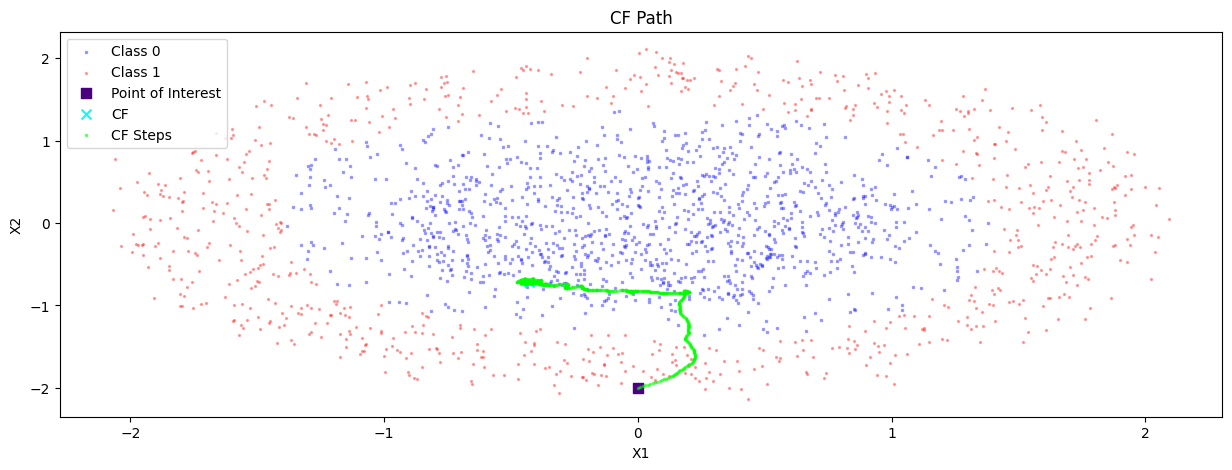

In [213]:
visualize_cf_and_steps(cf_connected,cf_steps_connected, data, y_pred_ensemble_points)

In [214]:
from property_procedures.connected import connectedness_procedure

cf_connected_au, cf_steps_connected_au = connectedness_procedure(point_of_interest,probability_function=ensemble_probs,aleatoric_uncertainty_function=aleatoric_uncertainty_ensemble, epistemic_uncertainty_function=epistemic_uncertainty_ensemble, desired_class=desired_class, MAX_STEPS=MAX_STEPS,n_points=10)

TypeError: connectedness_procedure() missing 1 required positional argument: 'reference_point'

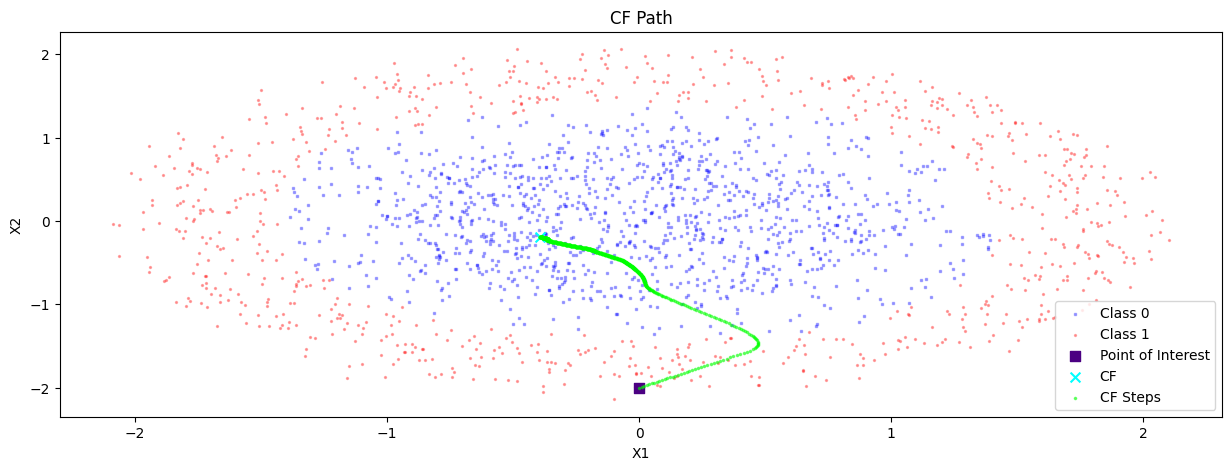

In [119]:
visualize_cf_and_steps(cf_connected_au,cf_steps_connected_au, data, y_pred_ensemble_points)

## Similarity

In [142]:
from property_procedures.similarity import similiarity_procedure

cf_similiar, cf_steps_similiar = similiarity_procedure(point_of_interest,probability_function=ensemble_probs,aleatoric_uncertainty_function=aleatoric_uncertainty_ensemble,desired_class=desired_class,MAX_STEPS=MAX_STEPS,n_points=10)

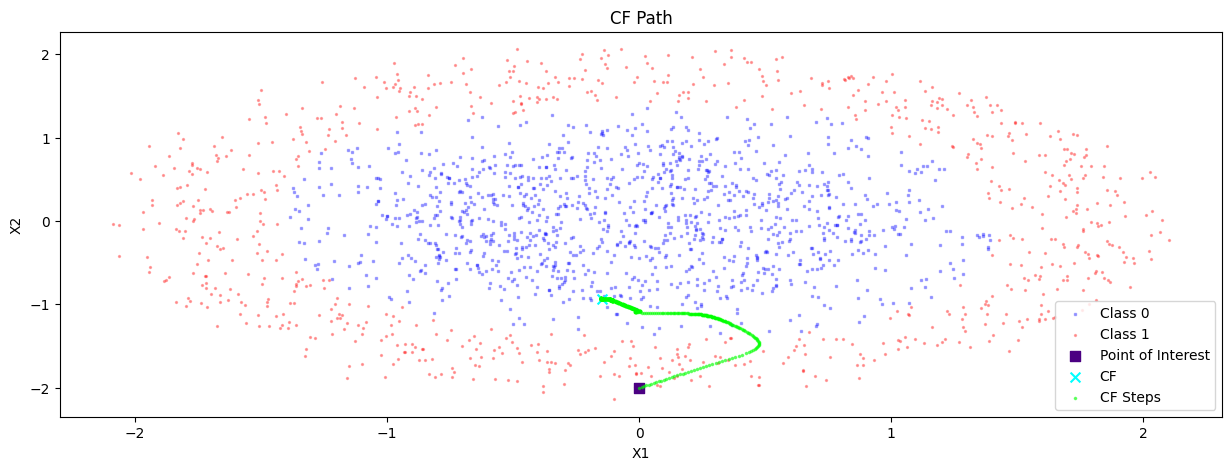

In [143]:
visualize_cf_and_steps(cf_similiar,cf_steps_similiar, data, y_pred_ensemble_points)

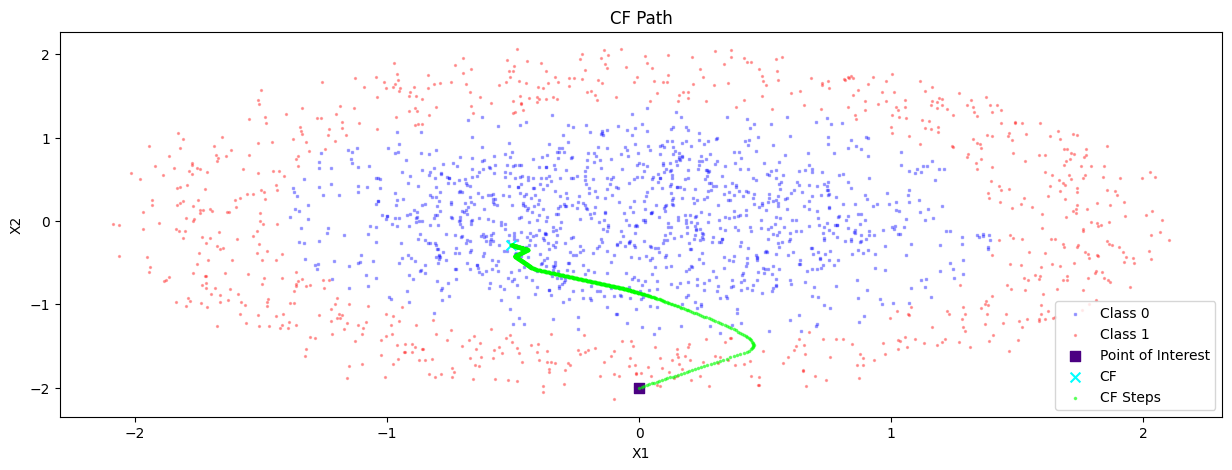

In [144]:
visualize_cf_and_steps(cf_valid,cf_steps_valid, data, y_pred_ensemble_points)

In [145]:
cf_similiar, cf_valid
print(point_of_interest)
torch.linalg.norm(cf_similiar - point_of_interest, ord=2),torch.linalg.norm(cf_valid - point_of_interest, ord=2)

tensor([[ 0., -2.]], requires_grad=True)


(tensor(1.0794, grad_fn=<AmaxBackward0>),
 tensor(1.7866, grad_fn=<AmaxBackward0>))

## Sparsisity

In [124]:
from property_procedures.sparse import sparse_procedure_iteratively, sparse_procedure_baseline
cf_sparse, cf_sparse_steps = sparse_procedure_iteratively(point_of_interest, probability_function=ensemble_probs, desired_class=desired_class, MAX_STEPS=MAX_STEPS, delta=0.2, n_points=10)
cf_sparse2, cf_sparse_steps2 = sparse_procedure_baseline(point_of_interest, probability_function=ensemble_probs,desired_class=desired_class, MAX_STEPS=MAX_STEPS, delta=0.2, n_points=10)

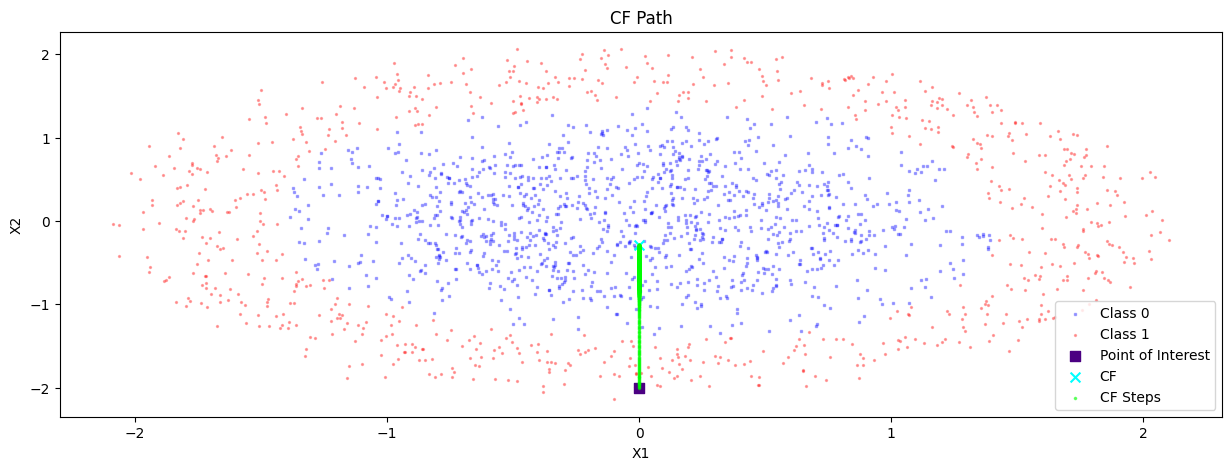

In [125]:
visualize_cf_and_steps(cf_sparse, cf_sparse_steps, data, y_pred_ensemble_points)

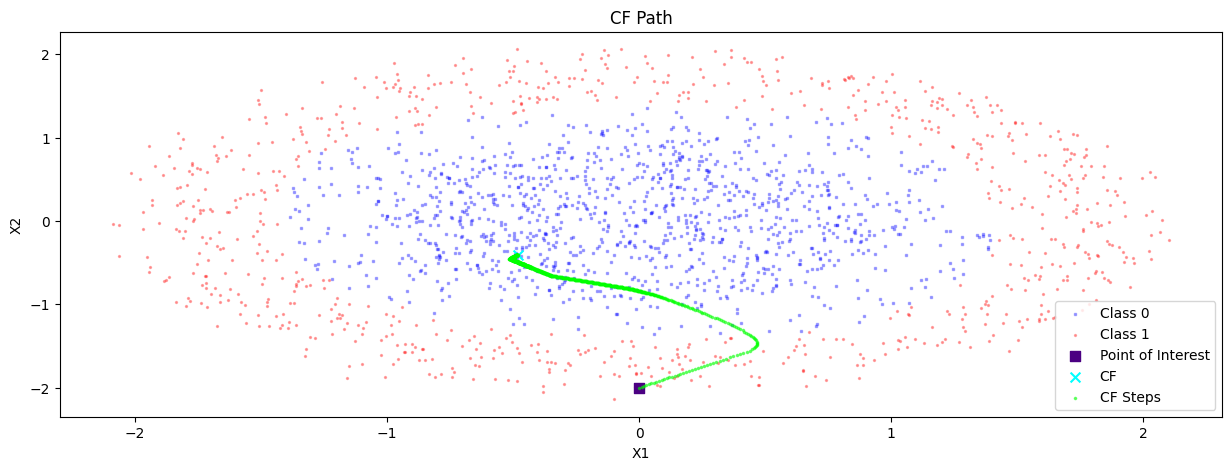

In [126]:
visualize_cf_and_steps(cf_sparse2, cf_sparse_steps2, data, y_pred_ensemble_points)

In [127]:
# Check how sparse the point is in contrast to validity
diff_valids = []
diff_sparse = []
diff_sparse2 = []
cf_valid, _ = validity_procedure(point_of_interest, desired_validity=0.9)
for _ in range(10):
    cf_sparse,_ = sparse_procedure_iteratively(point_of_interest,desired_validity=0.9, delta=0.2)
    cf_sparse2,_ = sparse_procedure_baseline(point_of_interest, desired_validity=0.9)
    diff_v = torch.norm(cf_valid - point_of_interest, p=1).item()
    diff_s = torch.norm(cf_sparse - point_of_interest, p=1).item()
    diff_s2 = torch.norm(cf_sparse2 - point_of_interest, p=1).item()
    diff_valids.append(diff_v)
    diff_sparse.append(diff_s)
    diff_sparse2.append(diff_s2)
print(f"Valid Diff: {np.mean(diff_valids)} +/- {np.std(diff_valids)}")
print(f"Sparse Diff: {np.mean(diff_sparse)} +/- {np.std(diff_sparse)}")
print(f"Sparse Diff: {np.mean(diff_sparse2)} +/- {np.std(diff_sparse2)}")

Valid Diff: 2.220444440841675 +/- 0.0
Sparse Diff: 1.7136441469192505 +/- 0.0
Sparse Diff: 2.0757944583892822 +/- 0.0


## Feasability

In [128]:
from sklearn.neighbors import NearestNeighbors


def get_knn_points(point,k=5):
    knn = NearestNeighbors(n_neighbors=k,algorithm="brute")
    knn.fit(data)
    distances, indices = knn.kneighbors(point.detach().numpy())
    return torch.tensor(data[indices]).requires_grad_(True)

def probability_point_given_data(point):
    knn_points = get_knn_points(point, k=5)
    max_distance = torch.linalg.norm(knn_points - point, ord=2,dim=1).max()
#    return 1/(1+torch.exp(max_distance))
    return 1/torch.exp(max_distance)

probability_point_given_data(point_of_interest.detach())

tensor(0.8189, grad_fn=<MulBackward0>)

torch.Size([10000, 10, 2])
tensor(0.0042, grad_fn=<MinBackward1>) tensor(1.0000, grad_fn=<MaxBackward1>)


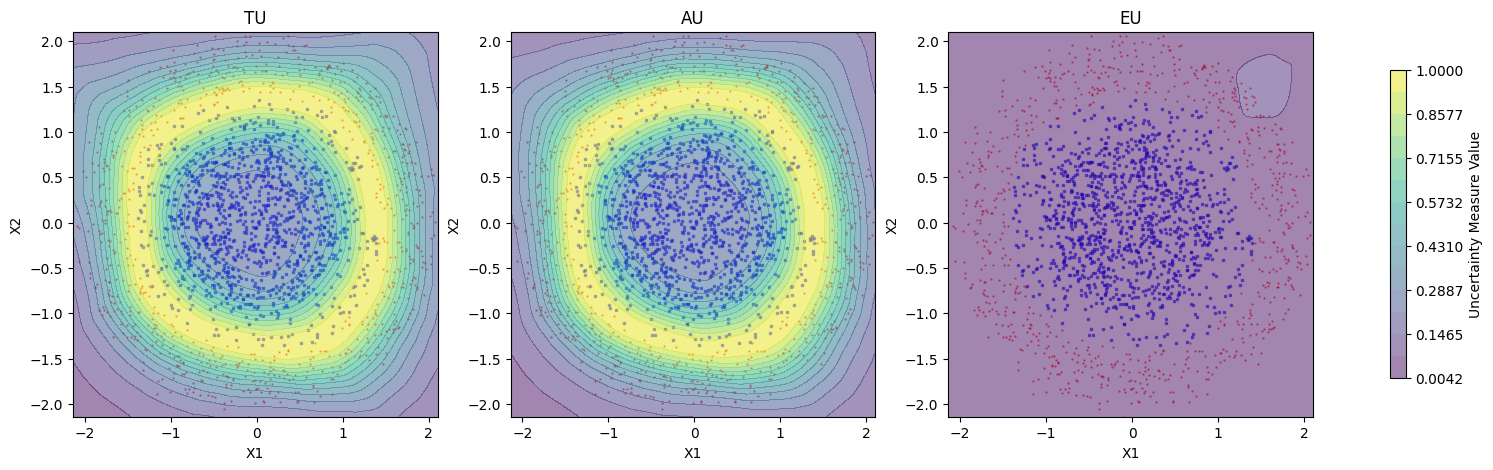

In [131]:
visualize_au_eu_tu_points(data,y_pred_ensemble_points)

In [132]:
from property_procedures.feasable import feasability_procedure

cf_feasable, cf_steps_feasable = feasability_procedure(point_of_interest, probability_function=ensemble_probs, epistemic_uncertainty_function=epistemic_uncertainty_ensemble, desired_class=desired_class, MAX_STEPS=MAX_STEPS, delta=.5,n_points=10)

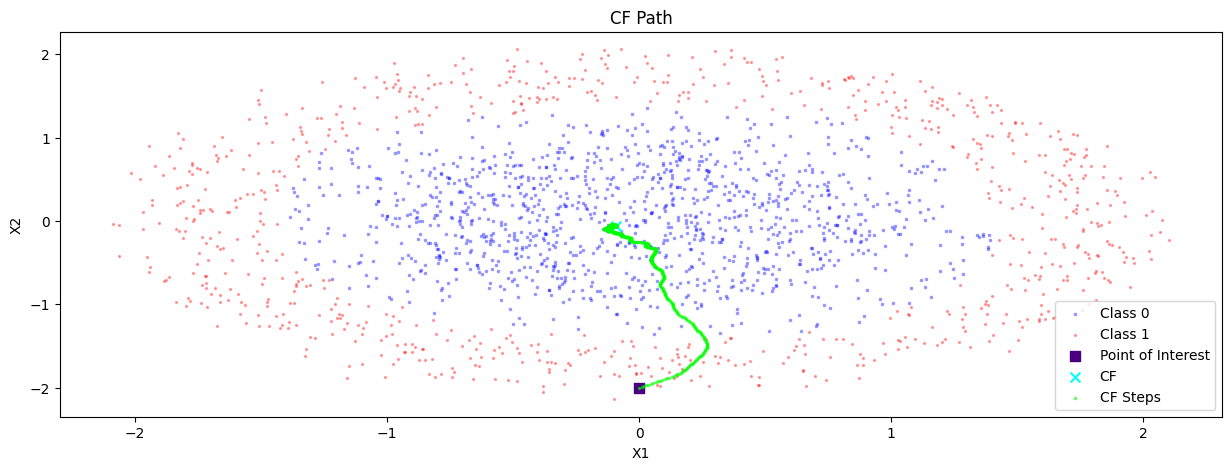

In [133]:
visualize_cf_and_steps(cf_feasable, cf_steps_feasable, data, y_pred_ensemble_points)

In [134]:
def feasability_procedure(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
    #delta_ball = get_knn_points(point_to_explain, k=n_points)
    probs_ensemble_delta_ball = ensemble_probs(delta_ball)
    probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
    tu_delta_ball_start = total_uncertainty_ensemble(probs_ensemble_delta_ball).detach()
    au_delta_ball_start = aleatoric_uncertainty_ensemble(probs_ensemble_delta_ball).detach()
    eu_delta_ball_start = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball).detach()
    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        eu = epistemic_uncertainty_ensemble(probs_ensemble)

        # total uncertainty of the point itself


        # # sample_ball
        delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
        #delta_ball = get_knn_points(counter_factual, k=n_points)
        probs_ensemble_delta_ball = ensemble_probs(delta_ball)
        probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
        au_delta_ball = aleatoric_uncertainty_ensemble(probs_ensemble_delta_ball)
        eu_delta_ball = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball)

        target_probs = probs[0,desired_class]
        target_probs_delta_ball = probs_delta_ball[:,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE
        # Calculate the loss#

        #loss = -target_probs + t*tu_point
        lam2 = 1 if target_probs > 0.5 else 0
        lam = 0.7
        loss = (-target_probs_delta_ball.mean()) + lam*( eu_delta_ball.std()) #- lam2*(au_delta_ball.max())
        #loss = (1-lam)*(-target_probs_delta_ball.mean()) + lam*tu_delta_ball.std()

        # Backpropagate
        loss.backward()
        counter_factual.grad = delta_ball.grad.mean(dim=0).view(-1,2)
        optimizer.step()

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_feasable, cf_steps_feasable = feasability_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY,delta=.5,n_points=10)

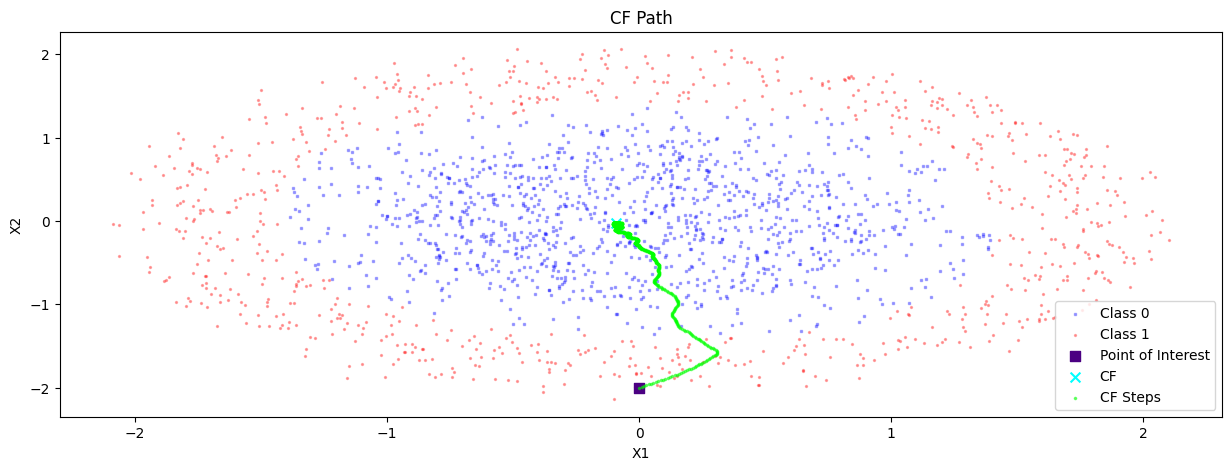

In [135]:
visualize_cf_and_steps(cf_feasable, cf_steps_feasable, data, y_pred_ensemble_points)